# ML-SFA Model Showcase

This notebook demonstrates all four SFA estimators implemented in ML-SFA:

1. **ParametricSFA** — Traditional MLE with Cobb-Douglas/Translog frontiers
2. **KernelSFA** — Local polynomial SFA with kernel-weighted MLE
3. **NNFrontierSFA** — Joint estimation NN-SFA with PyTorch
4. **BARTFrontierSFA** — Bayesian BART with PyMC-BART

Each model is applied to simulated data with known ground truth, so we can verify that the implementation correctly recovers technical efficiency.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from ml_sfa.data.simulator import simulate_sfa
from ml_sfa.evaluation.comparison import compare_models, results_to_dataframe

print("ML-SFA loaded successfully")

ML-SFA loaded successfully


## 1. Simulate Data

Generate a Cobb-Douglas production frontier with half-normal inefficiency.
Ground truth (true TE, true σ_v, σ_u) is known for validation.

In [2]:
ds = simulate_sfa(
    n_obs=500,
    n_inputs=2,
    frontier_type="cobb-douglas",
    inefficiency_dist="half-normal",
    sigma_v=0.15,
    sigma_u=0.30,
    seed=42,
)

print(f"Observations: {ds.n_obs}")
print(f"Inputs:       {ds.n_inputs}")
print(f"True σ_v:     {ds.sigma_v}")
print(f"True σ_u:     {ds.sigma_u}")
print(f"True mean TE: {np.mean(ds.te):.4f}")
print(f"X shape:      {ds.X.shape}")
print(f"y shape:      {ds.y.shape}")

Observations: 500
Inputs:       2
True σ_v:     0.15
True σ_u:     0.3
True mean TE: 0.7963
X shape:      (500, 2)
y shape:      (500,)


## 2. Model 1: ParametricSFA (Traditional MLE)

The standard parametric approach assumes a known functional form (Cobb-Douglas) for the frontier. Since the DGP is also Cobb-Douglas, this model should perform best.

In [3]:
from ml_sfa.models.parametric import ParametricSFA

psfa = ParametricSFA(frontier="cobb-douglas", inefficiency="half-normal")
psfa.fit(ds.X, ds.y)

te_psfa = psfa.efficiency(ds.X, ds.y)
s = psfa.summary()

print("=== ParametricSFA Results ===")
print(f"σ_v:  {s.sigma_v:.4f}  (true: {ds.sigma_v})")
print(f"σ_u:  {s.sigma_u:.4f}  (true: {ds.sigma_u})")
print(f"Mean TE:  {s.mean_efficiency:.4f}  (true: {np.mean(ds.te):.4f})")
print(f"Log-likelihood: {s.log_likelihood:.2f}")
print(f"AIC: {s.aic:.2f},  BIC: {s.bic:.2f}")
print(f"RMSE(TE): {np.sqrt(np.mean((ds.te - te_psfa)**2)):.4f}")
print(f"Rank ρ:   {spearmanr(ds.te, te_psfa).statistic:.4f}")
print(f"Coefficients: {psfa.coef_}")

=== ParametricSFA Results ===
σ_v:  0.1354  (true: 0.15)
σ_u:  0.3398  (true: 0.3)
Mean TE:  0.7727  (true: 0.7963)
Log-likelihood: 7.17
AIC: -4.33,  BIC: 16.74
RMSE(TE): 0.0880
Rank ρ:   0.7499
Coefficients: [1.00954145 0.38423243 0.47911855]


## 3. Model 2: KernelSFA (Local Polynomial MLE)

Nonparametric approach using kernel-weighted local MLE. No functional form assumption needed.

In [4]:
from ml_sfa.models.kernel_frontier import KernelSFA

ksfa = KernelSFA(inefficiency="half-normal", bandwidth="scott", seed=42)
ksfa.fit(ds.X, ds.y)

te_ksfa = ksfa.efficiency(ds.X, ds.y)
s = ksfa.summary()

print("=== KernelSFA Results ===")
print(f"σ_v (median): {s.sigma_v:.4f}  (true: {ds.sigma_v})")
print(f"σ_u (median): {s.sigma_u:.4f}  (true: {ds.sigma_u})")
print(f"Mean TE:  {s.mean_efficiency:.4f}  (true: {np.mean(ds.te):.4f})")
print(f"Log-likelihood: {s.log_likelihood:.2f}")
print(f"RMSE(TE): {np.sqrt(np.mean((ds.te - te_ksfa)**2)):.4f}")
print(f"Rank ρ:   {spearmanr(ds.te, te_ksfa).statistic:.4f}")

=== KernelSFA Results ===
σ_v (median): 0.1180  (true: 0.15)
σ_u (median): 0.3475  (true: 0.3)
Mean TE:  0.7941  (true: 0.7963)
Log-likelihood: 27.09
RMSE(TE): 0.1031
Rank ρ:   0.6635


## 4. Model 3: NNFrontierSFA (Joint Estimation NN)

Neural network frontier with simultaneous SFA error decomposition via PyTorch autograd. Two-phase optimization: MSE pretraining → SFA NLL fine-tuning.

In [5]:
try:
    from ml_sfa.models.nn_frontier import NNFrontierSFA

    nnsfa = NNFrontierSFA(
        inefficiency="half-normal",
        hidden_dims=[32, 16],
        pretrain_epochs=200,
        finetune_epochs=20,
        n_inits=3,
        seed=42,
    )
    nnsfa.fit(ds.X, ds.y)

    te_nnsfa = nnsfa.efficiency(ds.X, ds.y)
    s = nnsfa.summary()

    print("=== NNFrontierSFA Results ===")
    print(f"σ_v:  {s.sigma_v:.4f}  (true: {ds.sigma_v})")
    print(f"σ_u:  {s.sigma_u:.4f}  (true: {ds.sigma_u})")
    print(f"Mean TE:  {s.mean_efficiency:.4f}  (true: {np.mean(ds.te):.4f})")
    print(f"Log-likelihood: {s.log_likelihood:.2f}")
    print(f"N params: {s.n_params}")
    print(f"RMSE(TE): {np.sqrt(np.mean((ds.te - te_nnsfa)**2)):.4f}")
    print(f"Rank ρ:   {spearmanr(ds.te, te_nnsfa).statistic:.4f}")
    nn_available = True
except ImportError:
    print("torch not installed — skipping NNFrontierSFA")
    print("Install with: pip install ml-sfa[nn]")
    te_nnsfa = None
    nn_available = False

=== NNFrontierSFA Results ===
σ_v:  0.1633  (true: 0.15)
σ_u:  0.3510  (true: 0.3)
Mean TE:  0.7660  (true: 0.7963)
Log-likelihood: -39.09
N params: 643
RMSE(TE): 0.1007
Rank ρ:   0.6951


## 5. Model 4: BARTFrontierSFA (Bayesian BART)

Bayesian Additive Regression Trees with data-augmented MCMC. Provides posterior distributions for TE with credible intervals.

**Note:** MCMC sampling takes longer than other methods. We use a lightweight configuration here.

In [6]:
try:
    from ml_sfa.models.bart_frontier import BARTFrontierSFA

    bsfa = BARTFrontierSFA(
        inefficiency="half-normal",
        n_trees=20,
        n_draws=200,
        n_tune=200,
        n_chains=1,
        seed=42,
    )
    bsfa.fit(ds.X, ds.y)

    te_bsfa = bsfa.efficiency(ds.X, ds.y)
    s = bsfa.summary()

    print("=== BARTFrontierSFA Results ===")
    print(f"σ_v:  {s.sigma_v:.4f}  (true: {ds.sigma_v})")
    print(f"σ_u:  {s.sigma_u:.4f}  (true: {ds.sigma_u})")
    print(f"Mean TE:  {s.mean_efficiency:.4f}  (true: {np.mean(ds.te):.4f})")
    print(f"Log-likelihood (approx): {s.log_likelihood:.2f}")
    print(f"RMSE(TE): {np.sqrt(np.mean((ds.te - te_bsfa)**2)):.4f}")
    print(f"Rank ρ:   {spearmanr(ds.te, te_bsfa).statistic:.4f}")

    # Credible intervals — unique to Bayesian approach
    lower, upper = bsfa.credible_interval(ds.X, ds.y, alpha=0.05)
    coverage = np.mean((ds.te >= lower) & (ds.te <= upper))
    print(f"95% CI coverage: {coverage:.1%}")
    print(f"Mean CI width:   {np.mean(upper - lower):.4f}")
    bart_available = True
except ImportError:
    print("pymc/pymc-bart not installed — skipping BARTFrontierSFA")
    print("Install with: pip install ml-sfa[bart]")
    te_bsfa = None
    bart_available = False

Sequential sampling (1 chains in 1 job)


CompoundStep


>NUTS: [sigma_v, sigma_u, u]


>PGBART: [mu]


Sampling 1 chain for 200 tune and 200 draw iterations (200 + 200 draws total) took 3 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


=== BARTFrontierSFA Results ===
σ_v:  0.1663  (true: 0.15)
σ_u:  0.3181  (true: 0.3)
Mean TE:  0.7889  (true: 0.7963)
Log-likelihood (approx): -10.01
RMSE(TE): 0.0945
Rank ρ:   0.6735
95% CI coverage: 94.2%
Mean CI width:   0.3327


## 6. Visual Comparison: True TE vs Estimated TE

Scatter plots of true vs estimated technical efficiency for each model. Points closer to the diagonal indicate better recovery.

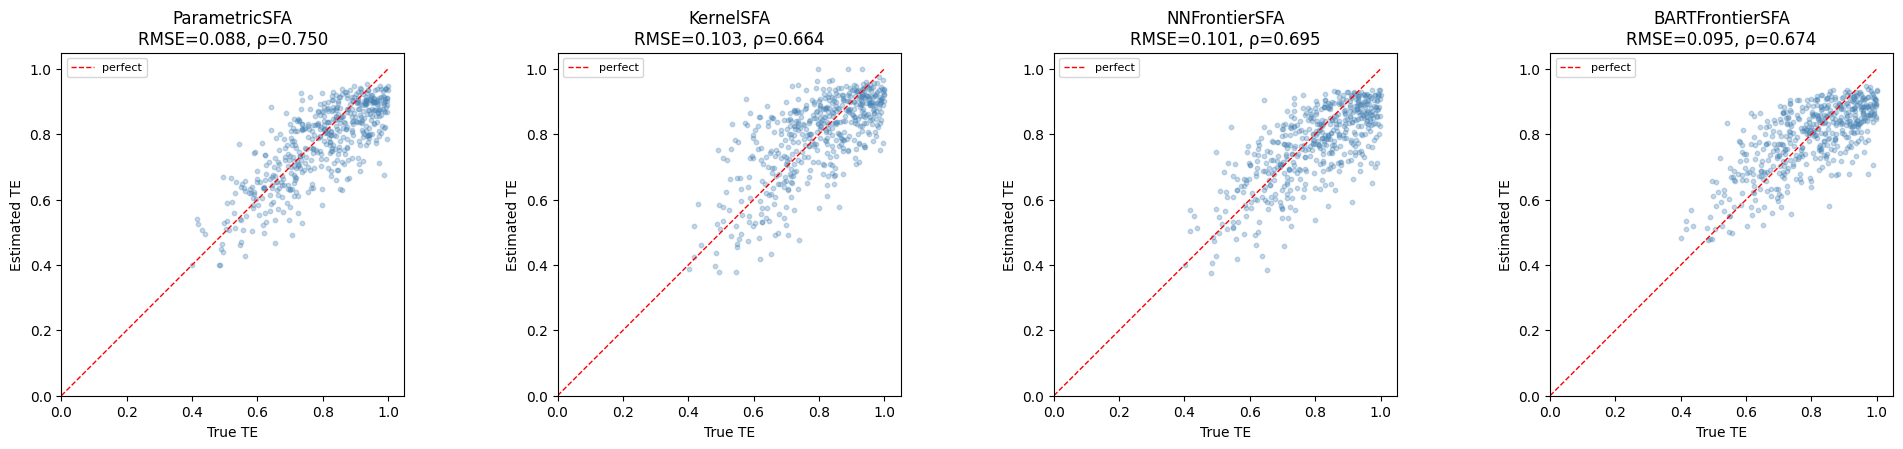

In [7]:
models_te = {"ParametricSFA": te_psfa, "KernelSFA": te_ksfa}
if nn_available:
    models_te["NNFrontierSFA"] = te_nnsfa
if bart_available:
    models_te["BARTFrontierSFA"] = te_bsfa

n_models = len(models_te)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5), squeeze=False)

for ax, (name, te_hat) in zip(axes[0], models_te.items()):
    rmse = np.sqrt(np.mean((ds.te - te_hat) ** 2))
    rho = spearmanr(ds.te, te_hat).statistic
    ax.scatter(ds.te, te_hat, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, 1], [0, 1], "r--", lw=1, label="perfect")
    ax.set_xlabel("True TE")
    ax.set_ylabel("Estimated TE")
    ax.set_title(f"{name}\nRMSE={rmse:.3f}, ρ={rho:.3f}")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Comparison Table

Use the built-in comparison framework to produce a summary table.

In [8]:
# Reuse already-fitted models (avoid re-running expensive BART MCMC)
import time

all_results = []
for name, te_hat in models_te.items():
    rmse = float(np.sqrt(np.mean((ds.te - te_hat) ** 2)))
    rho = float(spearmanr(ds.te, te_hat).statistic)
    true_frontier = ds.y - ds.v + ds.u
    # Get the fitted model object
    model_map = {"ParametricSFA": psfa, "KernelSFA": ksfa}
    if nn_available:
        model_map["NNFrontierSFA"] = nnsfa
    if bart_available:
        model_map["BARTFrontierSFA"] = bsfa
    m = model_map[name]
    pred = m.predict(ds.X)
    f_mse = float(np.mean((true_frontier - pred) ** 2))
    all_results.append({
        "model": name,
        "rmse_te": rmse,
        "rank_corr": rho,
        "frontier_mse": f_mse,
        "sigma_v": m.sigma_v_,
        "sigma_u": m.sigma_u_,
        "log_likelihood": m.log_likelihood(),
    })

import pandas as pd
df = pd.DataFrame(all_results).set_index("model")
display(df.round(4))

,rmse_te,rank_corr,frontier_mse,sigma_v,sigma_u,log_likelihood
model,,,,,,
ParametricSFA,0.0880,0.7499,0.0009,0.1354,0.3398,7.1669
KernelSFA,0.1031,0.6635,0.0062,0.1180,0.3475,27.0932
NNFrontierSFA,0.1007,0.6951,0.0103,0.1633,0.3510,-39.0883
BARTFrontierSFA,0.0945,0.6735,0.0089,0.1663,0.3181,-10.0114


## 8. Nonlinear DGP: Where ML Methods Shine

When the true frontier is nonlinear and cannot be captured by Cobb-Douglas or Translog, ML-based methods should outperform the parametric model.

In [9]:
ds_nl = simulate_sfa(
    n_obs=500,
    n_inputs=2,
    frontier_type="nonlinear",
    inefficiency_dist="half-normal",
    sigma_v=0.15,
    sigma_u=0.30,
    seed=42,
)
print(f"Nonlinear DGP: f(x) = β₀ + Σ βⱼ·xⱼ^0.6 + 0.3·sin(ln(x₁)·ln(x₂))")
print(f"True mean TE: {np.mean(ds_nl.te):.4f}")

# Fit Parametric (misspecified) and Kernel (flexible)
psfa_nl = ParametricSFA(frontier="cobb-douglas").fit(ds_nl.X, ds_nl.y)
ksfa_nl = KernelSFA(seed=42).fit(ds_nl.X, ds_nl.y)

te_psfa_nl = psfa_nl.efficiency(ds_nl.X, ds_nl.y)
te_ksfa_nl = ksfa_nl.efficiency(ds_nl.X, ds_nl.y)

print("\n--- Nonlinear DGP Results ---")
print(f"{'Model':<15} {'RMSE(TE)':>10} {'Rank ρ':>10}")
print("-" * 37)
for name, te_hat in [("Parametric", te_psfa_nl), ("Kernel", te_ksfa_nl)]:
    rmse = np.sqrt(np.mean((ds_nl.te - te_hat) ** 2))
    rho = spearmanr(ds_nl.te, te_hat).statistic
    print(f"{name:<15} {rmse:>10.4f} {rho:>10.4f}")

Nonlinear DGP: f(x) = β₀ + Σ βⱼ·xⱼ^0.6 + 0.3·sin(ln(x₁)·ln(x₂))
True mean TE: 0.7963



--- Nonlinear DGP Results ---
Model             RMSE(TE)     Rank ρ
-------------------------------------
Parametric          0.1050     0.6637
Kernel              0.1080     0.6330


## 9. sklearn Compatibility

All models support sklearn's `get_params()`, `set_params()`, and `clone()` — making them compatible with pipelines and grid search.

In [10]:
from sklearn.base import clone

# Demonstrate clone + get_params
original = ParametricSFA(frontier="translog", inefficiency="exponential")
cloned = clone(original)

print("Original params:", original.get_params())
print("Cloned params:  ", cloned.get_params())
print(f"Same params: {original.get_params() == cloned.get_params()}")
print(f"Different objects: {original is not cloned}")

Original params: {'cost': False, 'frontier': 'translog', 'inefficiency': 'exponential', 'max_iter': 1000, 'tol': 1e-08}
Cloned params:   {'cost': False, 'frontier': 'translog', 'inefficiency': 'exponential', 'max_iter': 1000, 'tol': 1e-08}
Same params: True
Different objects: True


## 10. Summary

| Model | Best for | Key advantage |
|-------|----------|---------------|
| **ParametricSFA** | Known functional form, large N | Lowest variance when correctly specified |
| **KernelSFA** | Moderate N, unknown frontier shape | No functional form assumption |
| **NNFrontierSFA** | Large N, complex nonlinear frontiers | Scales to N > 10,000, monotonicity constraints |
| **BARTFrontierSFA** | Small-moderate N, uncertainty quantification | Credible intervals for TE |

All models share the same `BaseSFAEstimator` API: `fit()`, `predict()`, `efficiency()`, `get_inefficiency()`, `get_noise()`, `log_likelihood()`, `summary()`.